In [ ]:
def minmax(node, ismax):
    # If the node is a number → return it
    if isinstance(node, int):
        return node, [node]

    best_path = []
    
    if ismax:
        best_value = float('-inf')
        for child in graph[node]:
            val, path = minmax(child, False)
            if val > best_value:
                best_value = val
                best_path = [node] + path
        return best_value, best_path

    else:
        best_value = float('inf')
        for child in graph[node]:
            val, path = minmax(child, True)
            if val < best_value:
                best_value = val
                best_path = [node] + path
        return best_value, best_path


graph = {
    'A': ['B', 'C'],
    'B': ['D', 'E'],
    'C': ['F', 'G'],
    'D': [3, 4],
    'E': [5, 6],
    'F': [7, 8],
    'G': [9, 10]
}

value, path = minmax('A', True)
print("Best value:", value)
print("Best path:", path)

In [10]:
def minmax(node, ismax):
    if isinstance(node, int):
        return node, [node]

    if ismax:
        bpath = []
        bvalue = float('-inf')
        for child in graph[node]:
            val, path = minmax(child, False)
            if val > bvalue:
                bvalue = val          # FIXED
                bpath = [node] + path
        return bvalue, bpath          # FIXED

    else:
        bpath = []
        bvalue = float('inf')
        for child in graph[node]:
            val, path = minmax(child, True)
            if val < bvalue:
                bvalue = val          # FIXED
                bpath = [node] + path
        return bvalue, bpath          # FIXED


graph = {
    'A': ['B', 'C'],   
    'B': ['D', 'E'],
    'C': ['F', 'G'],
    'D': [3, 4],
    'E': [5, 6],
    'F': [7, 8],
    'G': [9, 10]
}

value, path = minmax('A', True)
print("Best value:", value)
print("Best path:", path)

Best value: 8
Best path: ['A', 'C', 'F', 8]


In [13]:
def alphabeta(node,ismax,alpha,beta):
    if isinstance(node,int):
        return node,[node]
    if ismax:
        bpath = []
        bvalue = float('-inf')
        for child in graph[node]:
            val,path=alphabeta(child,False,alpha,beta)
            if val > bvalue:
                bvalue = val
                bpath = [node] + path
            alpha = max(alpha,bvalue)
            if beta <= alpha:
                break               
        return bvalue,bpath
    else:
        bpath = []
        bvalue = float('inf')
        for child in graph[node]:
            val,path=alphabeta(child,True,alpha,beta)
            if val < bvalue:
                bvalue = val
                bpath = [node] + path
            beta = min(beta,bvalue)
            if beta <= alpha:
                break               
        return bvalue,bpath

graph = {
    'A': ['B', 'C'],
    'B': ['D', 'E'],
    'C': ['F', 'G'],
    'D': [3, 4],
    'E': [5, 6],
    'F': [7, 8],
    'G': [9, 10]
}
value, path = alphabeta('A', True, float('-inf'), float('inf'))
print("Best value:", value)
print("Best path:", path)

Best value: 8
Best path: ['A', 'C', 'F', 8]


In [14]:
from ortools.sat.python import cp_model
model=cp_model.CpModel()
x = model.NewIntVar(0, 2, "x")
y = model.NewIntVar(0, 2, "y")
model.AddAllDifferent([x,y])
solver=cp_model.CpSolver()
status=solver.Solve(model)
if status==cp_model.OPTIMAL:
 print(solver.Value(x))
 print(solver.Value(y))
else:
   print("no solution exist")

0
2


In [15]:
#for all the solution
class allsol(cp_model.CpSolverSolutionCallback):
    def __init__(self,variables):
        cp_model.CpSolverSolutionCallback.__init__(self)
        self.__variables=variables
    def on_solution_callback(self):
        for v in self.__variables:
            print(f"{v}={self.Value(v)}",end=" ")
        print() 
model=cp_model.CpModel()
x = model.NewIntVar(0, 2, "x")
y = model.NewIntVar(0, 2, "y")
model.AddAllDifferent([x,y])
solver=cp_model.CpSolver()
solution_printer=allsol([x,y])
status=solver.SearchForAllSolutions(model,solution_printer)


x=1 y=0 
x=2 y=0 
x=2 y=1 
x=1 y=2 
x=0 y=2 
x=0 y=1 


In [17]:
from ortools.sat.python import cp_model

# =========================
# 1. CREATE MODEL
# =========================
model = cp_model.CpModel()

# =========================
# 2. CREATE VARIABLES (REAL TEMPLATE)
# =========================
# Example: decision variables (you can replace this block)

n = 4  # number of items (jobs / nodes / students etc.)

x = []
for i in range(n):
    x.append(model.NewIntVar(0, 3, f"x_{i}"))


# =========================
# 3. ADD CONSTRAINTS (CORE UNIVERSAL RULES)
# =========================

# (A) AllDifferent → used in Sudoku / scheduling / coloring
model.AddAllDifferent(x)

# (B) Example linear constraints (real-world limitation)
model.Add(x[0] + x[1] <= 3)
model.Add(x[2] != x[3])

# (C) Generic pairwise constraint (used in graph coloring)
for i in range(n):
    for j in range(i + 1, n):
        model.Add(x[i] != x[j])  # safe universal constraint


# =========================
# 4. OBJECTIVE (OPTIONAL)
# =========================
model.Minimize(sum(x))


# =========================
# 5. SOLVER
# =========================
solver = cp_model.CpSolver()
status = solver.Solve(model)


# =========================
# 6. OUTPUT
# =========================
if status in (cp_model.OPTIMAL, cp_model.FEASIBLE):
    print("Solution Found:")
    for i in range(n):
        print(f"x[{i}] =", solver.Value(x[i]))
else:
    print("No solution exists")

Solution Found:
x[0] = 0
x[1] = 1
x[2] = 2
x[3] = 3


In [ ]:
from ortools.sat.python import cp_model
model=cp_model.CpModel()
cell=[]
for i in range(4):
    row=[]
    for j in range(4):
        row.append(model.NewIntVar(1,4,f"cell[{i}][{j}]"))
    cell.append(row)
solver=cp_model.CpSolver()


In [21]:
from ortools.sat.python import cp_model

vertices = ["A","B","C","D"]
edges = [("A","B"),("A","C"),("B","D"),("C","D")]

model = cp_model.CpModel()

color = {}
numcolors = 3

for v in vertices:
    color[v] = model.NewIntVar(1, numcolors, f"color_{v}")

print(color)

for (u, v) in edges:
    model.Add(color[u] != color[v])

class allsol(cp_model.CpSolverSolutionCallback):
    def __init__(self, variables):
        super().__init__()
        self.variables = variables

    def OnSolutionCallback(self):
        for v in self.variables:
            print(f"{v}={self.Value(v)}", end=" ")
        print()

solver = cp_model.CpSolver()
solution_printer = allsol([color[v] for v in vertices])

status = solver.SearchForAllSolutions(model, solution_printer)

{'A': color_A(1..3), 'B': color_B(1..3), 'C': color_C(1..3), 'D': color_D(1..3)}
color_A=1 color_B=2 color_C=2 color_D=3 
color_A=2 color_B=1 color_C=1 color_D=3 
color_A=2 color_B=1 color_C=1 color_D=2 
color_A=2 color_B=3 color_C=1 color_D=2 
color_A=2 color_B=3 color_C=3 color_D=2 
color_A=1 color_B=3 color_C=3 color_D=2 
color_A=2 color_B=1 color_C=3 color_D=2 
color_A=2 color_B=3 color_C=3 color_D=1 
color_A=1 color_B=3 color_C=3 color_D=1 
color_A=1 color_B=2 color_C=3 color_D=1 
color_A=1 color_B=2 color_C=2 color_D=1 
color_A=1 color_B=3 color_C=2 color_D=1 
color_A=3 color_B=1 color_C=2 color_D=3 
color_A=3 color_B=1 color_C=1 color_D=3 
color_A=3 color_B=1 color_C=1 color_D=2 
color_A=3 color_B=2 color_C=1 color_D=3 
color_A=3 color_B=2 color_C=2 color_D=3 
color_A=3 color_B=2 color_C=2 color_D=1 


In [22]:
from ortools.sat.python import cp_model

# -------------------------
# EXAMS
# -------------------------
exams = ["Math", "Physics", "CS", "AI"]

# -------------------------
# CONFLICTS (students taking both exams)
# if two exams are connected → cannot be same time slot
# -------------------------
conflicts = [
    ("Math", "Physics"),
    ("Math", "CS"),
    ("Physics", "AI"),
    ("CS", "AI")
]

# -------------------------
# MODEL
# -------------------------
model = cp_model.CpModel()

num_slots = 3  # time slots

# -------------------------
# VARIABLES
# exam[i] = time slot
# -------------------------
slot = {}
for e in exams:
    slot[e] = model.NewIntVar(0, num_slots - 1, f"slot_{e}")

# -------------------------
# CONSTRAINTS
# -------------------------

# 1. Conflicting exams cannot be at same time
for (e1, e2) in conflicts:
    model.Add(slot[e1] != slot[e2])

# -------------------------
# SOLVER
# -------------------------
solver = cp_model.CpSolver()
status = solver.Solve(model)

# -------------------------
# OUTPUT
# -------------------------
if status in (cp_model.OPTIMAL, cp_model.FEASIBLE):
    print("TIMETABLE:\n")
    for e in exams:
        print(e, "-> Slot", solver.Value(slot[e]))
else:
    print("No valid timetable found")

TIMETABLE:

Math -> Slot 0
Physics -> Slot 1
CS -> Slot 1
AI -> Slot 0


In [ ]:
from pgmpy import BayesianModel
model = BayesianModel([('A', 'C'), ('B', 'C')])

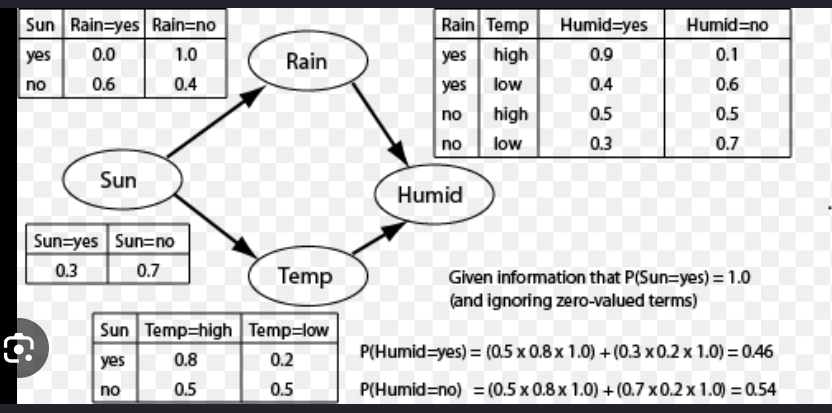

In [29]:
from pgmpy.models import BayesianNetwork
from pgmpy.factors.discrete import TabularCPD
from pgmpy.inference import VariableElimination

# ======================================================
# 1. STRUCTURE
# ======================================================
model = DiscreteBayesianNetwork([
    ("Sun", "Rain"),
    ("Sun", "Temp"),
    ("Rain", "Humid"),
    ("Temp", "Humid")
])

# ======================================================
# 2. CPDs
# ======================================================

cpd_sun = TabularCPD(
    variable="Sun",
    variable_card=2,
    values=[[0.7], [0.3]]
)

cpd_rain = TabularCPD(
    variable="Rain",
    variable_card=2,
    values=[
        [0.0, 0.6],  # Rain=yes
        [1.0, 0.4]   # Rain=no
    ],
    evidence=["Sun"],
    evidence_card=[2]
)

cpd_temp = TabularCPD(
    variable="Temp",
    variable_card=2,
    values=[
        [0.8, 0.5],  # high
        [0.2, 0.5]   # low
    ],
    evidence=["Sun"],
    evidence_card=[2]
)

cpd_humid = TabularCPD(
    variable="Humid",
    variable_card=2,
    values=[
        [0.9, 0.4, 0.5, 0.3],
        [0.1, 0.6, 0.5, 0.7]
    ],
    evidence=["Rain", "Temp"],
    evidence_card=[2, 2]
)

# ======================================================
# 3. ADD CPDs
# ======================================================
model.add_cpds(cpd_sun, cpd_rain, cpd_temp, cpd_humid)

print("Model valid:", model.check_model())

# ======================================================
# 4. INFERENCE
# ======================================================
infer = VariableElimination(model)

# ======================================================
# 5. QUERIES
# ======================================================

print("\nP(Humid | Sun=yes):")
print(infer.query(["Humid"], evidence={"Sun": 1}))

print("\nP(Humid | Sun=no, Rain=yes):")
print(infer.query(["Humid"], evidence={"Sun": 0, "Rain": 1}))

Model valid: True

P(Humid | Sun=yes):


AttributeError: module 'networkx' has no attribute 'bfs_edges'

In [30]:
import pandas as pd
df=pd.read_csv("patients.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 974 entries, 0 to 973
Data columns (total 20 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Id          974 non-null    object 
 1   BIRTHDATE   974 non-null    object 
 2   DEATHDATE   154 non-null    object 
 3   PREFIX      974 non-null    object 
 4   FIRST       974 non-null    object 
 5   LAST        974 non-null    object 
 6   SUFFIX      21 non-null     object 
 7   MAIDEN      386 non-null    object 
 8   MARITAL     973 non-null    object 
 9   RACE        974 non-null    object 
 10  ETHNICITY   974 non-null    object 
 11  GENDER      974 non-null    object 
 12  BIRTHPLACE  974 non-null    object 
 13  ADDRESS     974 non-null    object 
 14  CITY        974 non-null    object 
 15  STATE       974 non-null    object 
 16  COUNTY      974 non-null    object 
 17  ZIP         832 non-null    float64
 18  LAT         974 non-null    float64
 19  LON         974 non-null    f


===== DATA INFO =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 974 entries, 0 to 973
Data columns (total 20 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Id          974 non-null    object 
 1   BIRTHDATE   974 non-null    object 
 2   DEATHDATE   154 non-null    object 
 3   PREFIX      974 non-null    object 
 4   FIRST       974 non-null    object 
 5   LAST        974 non-null    object 
 6   SUFFIX      21 non-null     object 
 7   MAIDEN      386 non-null    object 
 8   MARITAL     973 non-null    object 
 9   RACE        974 non-null    object 
 10  ETHNICITY   974 non-null    object 
 11  GENDER      974 non-null    object 
 12  BIRTHPLACE  974 non-null    object 
 13  ADDRESS     974 non-null    object 
 14  CITY        974 non-null    object 
 15  STATE       974 non-null    object 
 16  COUNTY      974 non-null    object 
 17  ZIP         832 non-null    float64
 18  LAT         974 non-null    float64
 19  LON   

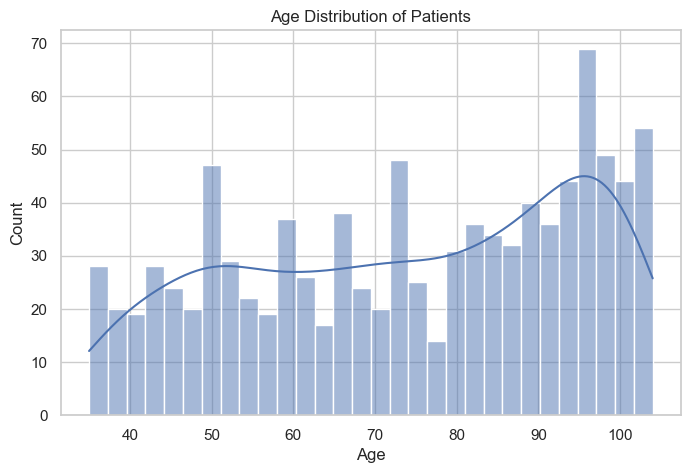

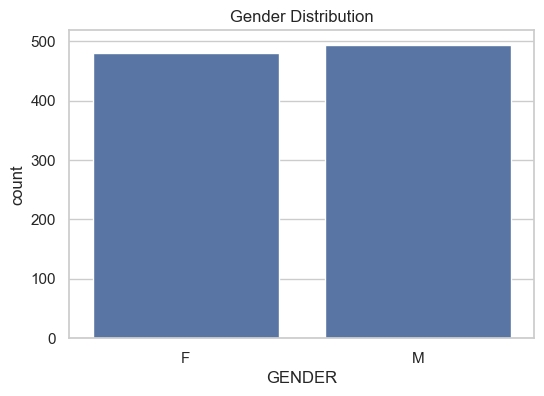

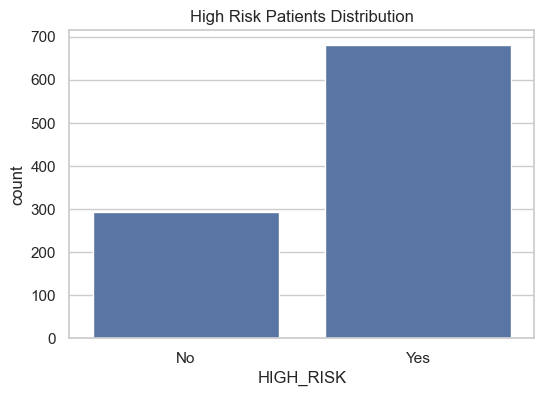

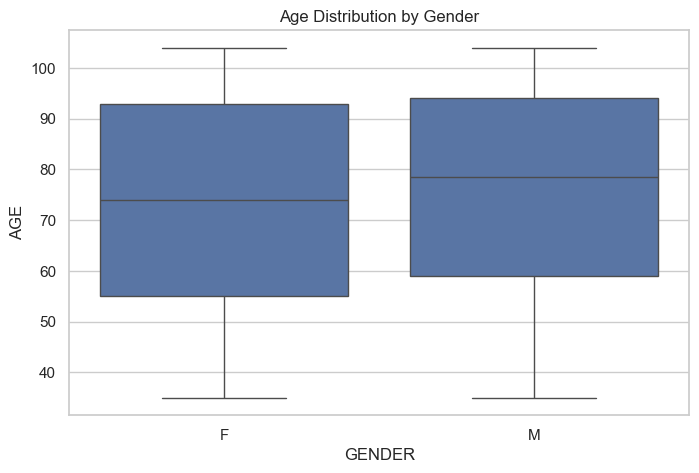

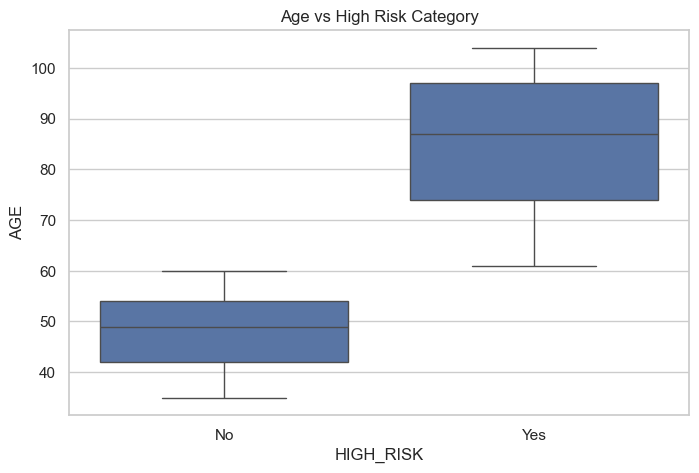

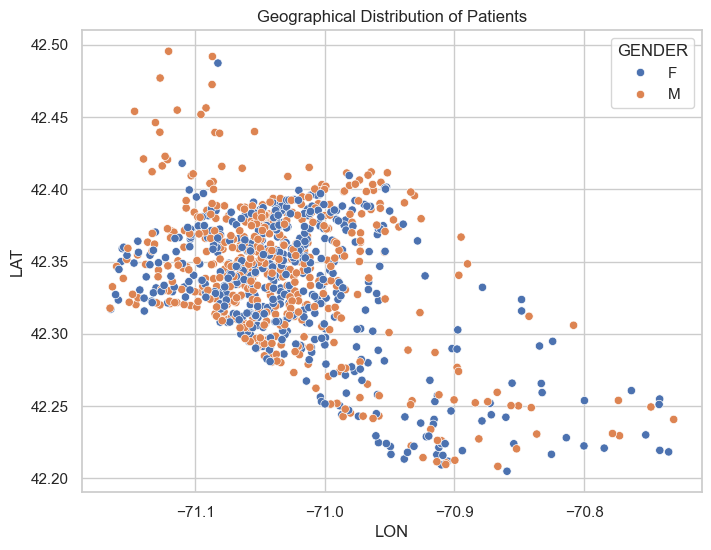

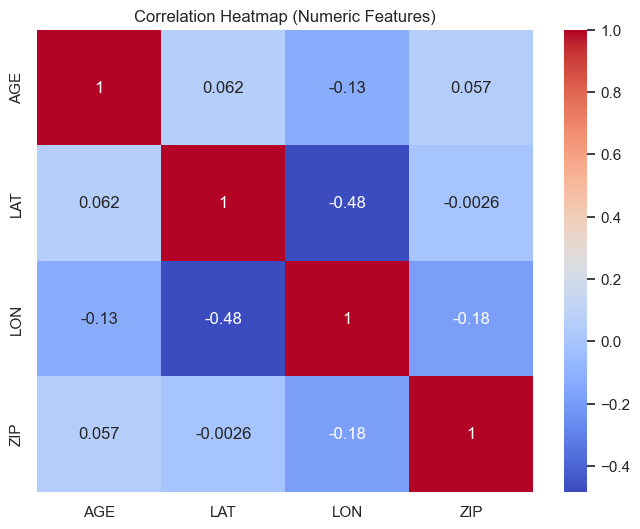

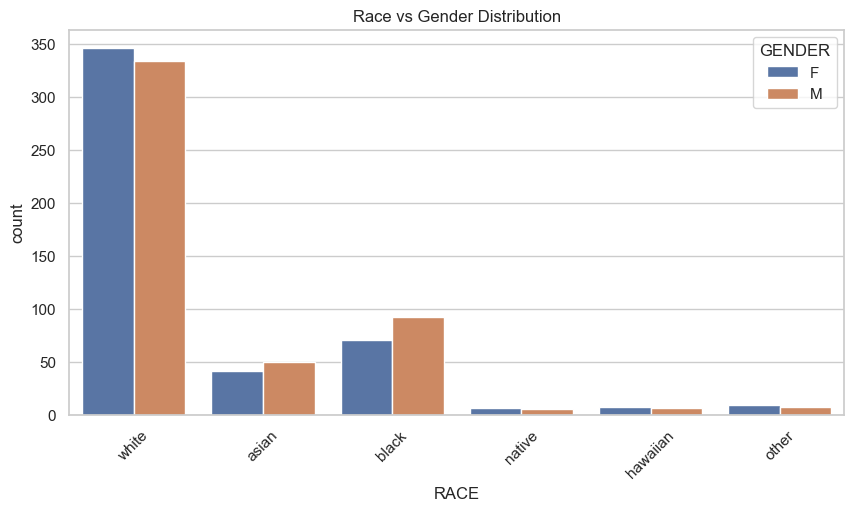

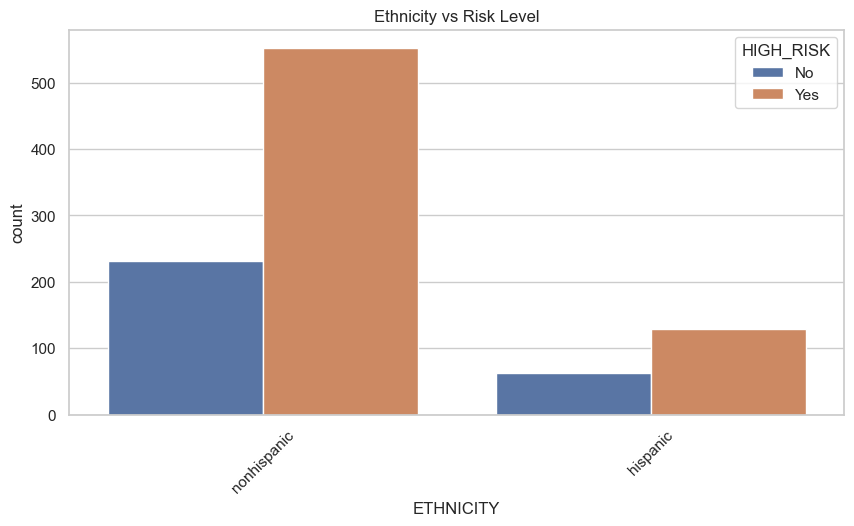

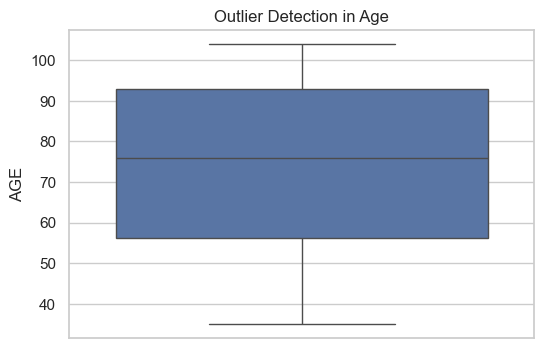

In [31]:
# =========================================================
# 0. IMPORTS
# =========================================================
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Optional style (makes plots cleaner)
sns.set(style="whitegrid")

# =========================================================
# 1. LOAD DATA
# =========================================================
df = pd.read_csv("patients.csv")

print("\n===== DATA INFO =====")
print(df.info())

print("\n===== FIRST 5 ROWS =====")
print(df.head())

# =========================================================
# 2. BASIC DATA UNDERSTANDING
# =========================================================

print("\n===== MISSING VALUES =====")
print(df.isnull().sum())

print("\n===== STATISTICAL SUMMARY (NUMERIC) =====")
print(df.describe())

print("\n===== CATEGORICAL SUMMARY =====")
print(df.describe(include="object"))

# =========================================================
# 3. DATA CLEANING (ONLY EDA LEVEL)
# =========================================================

df["DEATHDATE"] = df["DEATHDATE"].fillna("Alive")
df["SUFFIX"] = df["SUFFIX"].fillna("None")
df["MAIDEN"] = df["MAIDEN"].fillna("None")
df["ZIP"] = df["ZIP"].fillna(df["ZIP"].mode()[0])

# =========================================================
# 4. FEATURE ENGINEERING (FOR VISUALIZATION)
# =========================================================

df["BIRTHDATE"] = pd.to_datetime(df["BIRTHDATE"], errors="coerce")
df["AGE"] = 2026 - df["BIRTHDATE"].dt.year

# Risk category (for visualization only)
df["HIGH_RISK"] = np.where(df["AGE"] > 60, "Yes", "No")

# =========================================================
# 5. UNIVARIATE ANALYSIS (SINGLE VARIABLES)
# =========================================================

# -----------------------------
# 1. Age Distribution
# -----------------------------
plt.figure(figsize=(8,5))
sns.histplot(df["AGE"], bins=30, kde=True)
plt.title("Age Distribution of Patients")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

# -----------------------------
# 2. Gender Distribution
# -----------------------------
plt.figure(figsize=(6,4))
sns.countplot(x="GENDER", data=df)
plt.title("Gender Distribution")
plt.show()

# -----------------------------
# 3. High Risk Distribution
# -----------------------------
plt.figure(figsize=(6,4))
sns.countplot(x="HIGH_RISK", data=df)
plt.title("High Risk Patients Distribution")
plt.show()

# =========================================================
# 6. BIVARIATE ANALYSIS (RELATIONSHIPS)
# =========================================================

# -----------------------------
# 4. Age vs Gender
# -----------------------------
plt.figure(figsize=(8,5))
sns.boxplot(x="GENDER", y="AGE", data=df)
plt.title("Age Distribution by Gender")
plt.show()

# -----------------------------
# 5. Age vs Risk
# -----------------------------
plt.figure(figsize=(8,5))
sns.boxplot(x="HIGH_RISK", y="AGE", data=df)
plt.title("Age vs High Risk Category")
plt.show()

# =========================================================
# 7. GEOGRAPHICAL ANALYSIS
# =========================================================

# -----------------------------
# 6. Latitude vs Longitude (Patient Spread)
# -----------------------------
plt.figure(figsize=(8,6))
sns.scatterplot(x="LON", y="LAT", hue="GENDER", data=df)
plt.title("Geographical Distribution of Patients")
plt.show()

# =========================================================
# 8. CORRELATION ANALYSIS
# =========================================================

numeric_cols = ["AGE", "LAT", "LON", "ZIP"]

plt.figure(figsize=(8,6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap (Numeric Features)")
plt.show()

# =========================================================
# 9. CATEGORICAL RELATIONSHIPS
# =========================================================

# Race vs Gender
plt.figure(figsize=(10,5))
sns.countplot(x="RACE", hue="GENDER", data=df)
plt.title("Race vs Gender Distribution")
plt.xticks(rotation=45)
plt.show()

# Ethnicity vs Risk
plt.figure(figsize=(10,5))
sns.countplot(x="ETHNICITY", hue="HIGH_RISK", data=df)
plt.title("Ethnicity vs Risk Level")
plt.xticks(rotation=45)
plt.show()

# =========================================================
# 10. OUTLIER CHECK (AGE)
# =========================================================

plt.figure(figsize=(6,4))
sns.boxplot(y="AGE", data=df)
plt.title("Outlier Detection in Age")
plt.show()

In [32]:
# =========================================================
# 0. IMPORTS
# =========================================================
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score

from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.cluster import KMeans

from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, r2_score
)

# =========================================================
# 1. LOAD DATA
# =========================================================
df = pd.read_csv("patients.csv")

# =========================================================
# 2. BASIC CLEANING
# =========================================================
df["DEATHDATE"] = df["DEATHDATE"].fillna("Alive")
df["SUFFIX"] = df["SUFFIX"].fillna("None")
df["MAIDEN"] = df["MAIDEN"].fillna("None")
df["ZIP"] = df["ZIP"].fillna(df["ZIP"].mode()[0])

# =========================================================
# 3. FEATURE ENGINEERING
# =========================================================
df["BIRTHDATE"] = pd.to_datetime(df["BIRTHDATE"], errors="coerce")
df["AGE"] = 2026 - df["BIRTHDATE"].dt.year

# Target (classification problem)
df["HIGH_RISK"] = (df["AGE"] > 60).astype(int)

# =========================================================
# 4. ENCODING
# =========================================================
categorical_cols = ["GENDER", "RACE", "ETHNICITY", "MARITAL", "STATE"]

le_dict = {}

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    le_dict[col] = le

# =========================================================
# 5. FEATURES & TARGET
# =========================================================
features = ["AGE", "LAT", "LON", "ZIP", "GENDER", "RACE", "ETHNICITY"]

X = df[features]
y = df["HIGH_RISK"]

# =========================================================
# 6. TRAIN TEST SPLIT
# =========================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =========================================================
# 7. SCALING (IMPORTANT RULE)
# - Needed: Logistic, KNN, SVM
# - Not needed: Trees, RF, Naive Bayes
# =========================================================
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# =========================================================
# 8. CLASSIFICATION MODELS (MAIN CHEAT SECTION)
# =========================================================

models = {
    "Logistic Regression": LogisticRegression(),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(),
    "Naive Bayes": GaussianNB()
}

print("\n================ CLASSIFICATION RESULTS ================\n")

for name, model in models.items():

    # Apply scaling only where needed
    if name in ["Logistic Regression", "KNN", "SVM"]:
        model.fit(X_train_scaled, y_train)
        preds = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        preds = model.predict(X_test)

    acc = accuracy_score(y_test, preds)

    print(f"{name}: {acc:.4f}")

# =========================================================
# 9. DETAILED MODEL REPORT (LOGISTIC REGRESSION)
# =========================================================
log_model = LogisticRegression()
log_model.fit(X_train_scaled, y_train)

log_pred = log_model.predict(X_test_scaled)

print("\nConfusion Matrix:\n", confusion_matrix(y_test, log_pred))
print("\nClassification Report:\n", classification_report(y_test, log_pred))

# =========================================================
# 10. LINEAR REGRESSION (FOR LEARNING PURPOSE ONLY)
# =========================================================
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)

print("\nLinear Regression R2 Score:", r2_score(y_test, lr_pred))

# =========================================================
# 11. K-MEANS CLUSTERING (UNSUPERVISED)
# =========================================================
kmeans = KMeans(n_clusters=3, random_state=42)

clusters = kmeans.fit_predict(scaler.fit_transform(X))

df["Cluster"] = clusters

print("\nCluster counts:")
print(df["Cluster"].value_counts())

# =========================================================
# 12. CROSS VALIDATION (IMPORTANT EXAM TOOL)
# =========================================================
cv_scores = cross_val_score(
    LogisticRegression(max_iter=200),
    X_train_scaled,
    y_train,
    cv=5
)

print("\nCross Validation Score:", cv_scores.mean())


================ CLASSIFICATION RESULTS ================

Logistic Regression: 0.9949
KNN: 0.9179
Decision Tree: 1.0000
Random Forest: 1.0000
SVM: 0.9692
Naive Bayes: 0.9795

Confusion Matrix:
 [[ 63   0]
 [  1 131]]

Classification Report:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99        63
           1       1.00      0.99      1.00       132

    accuracy                           0.99       195
   macro avg       0.99      1.00      0.99       195
weighted avg       0.99      0.99      0.99       195


Linear Regression R2 Score: 0.6621089360996008

Cluster counts:
Cluster
1    439
0    405
2    130
Name: count, dtype: int64

Cross Validation Score: 0.9935897435897436
